<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/LangStudio/RSI_Backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## RSI Analysis

This code performs a comprehensive parameter sweep for an RSI trading strategy across multiple symbols, RSI lengths, and RSI entry thresholds. It calculates 3, 5, and 10-day forward returns and win rates for each parameter combination, then summarizes and sorts the results to identify optimal strategy configurations.

In [2]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

In [3]:
# RSI Analysis

# --- 1. Configuration & Symbol Loading ---
RSI_LEVELS = [25, 30, 35, 40]
RSI_LENGTHS = [3, 5, 7, 10, 12, 14, 16, 18, 22, 24, 26]

# Load Symbols from your OptionVolume200.csv
try:
    df_csv = pd.read_csv(OptionVolume200)
    # Ensuring we handle different possible column names for Symbol
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume200")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT"]

# --- 2. Enhanced RSI Function (Wilder's Smoothing) ---
def calculate_rsi_yahoo(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# --- 3. Data Fetching & Vectorized Math ---
print("Fetching data and calculating vectorized returns...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, period="5y", interval="1d", progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # VECTORIZED RETURN CALCULATION
        # Calculate percentage change and shift it backward to see future results
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep ---
all_results = []
all_trades_list = [] # New list to store all individual trades for all_combined_trades_df

for rsi_len in RSI_LENGTHS:
    for rsi_thresh in RSI_LEVELS:
        param_trades = []

        for symbol, df_orig in data_cache.items():
            df = df_orig.copy()
            df['RSI'] = calculate_rsi_yahoo(df['Close'], period=rsi_len)

            condition = (df['RSI'] < rsi_thresh) & (df['RSI'].shift(1) >= rsi_thresh)

            # Filter for the specific trigger day
            trades = df[condition].dropna(subset=['RSI', 'Ret_10D']).copy()

            if not trades.empty:
                trades['RSI_Len'] = rsi_len
                trades['RSI_Thresh'] = rsi_thresh
                trades['Symbol'] = symbol
                param_trades.append(trades)
                all_trades_list.append(trades) # Append to the new list

        if param_trades:
            combined = pd.concat(param_trades)
            all_results.append({
                "RSI_Len": rsi_len,
                "RSI_Thresh": rsi_thresh,
                "Avg_3D": combined['Ret_3D'].mean(),
                "Avg_5D": combined['Ret_5D'].mean(),
                "Avg_10D": combined['Ret_10D'].mean(),
                "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                "Trade_Count": len(combined)
            })

# After all loops, create the all_combined_trades_df
if all_trades_list:
    all_combined_trades_df = pd.concat(all_trades_list)
    # Ensure the index is a DatetimeIndex
    all_combined_trades_df.index = pd.to_datetime(all_combined_trades_df.index)
else:
    all_combined_trades_df = pd.DataFrame() # Create an empty DataFrame if no trades

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    # Sorting by 5D return as it's been our benchmark
    summary_df = summary_df.sort_values(by="Avg_5D", ascending=False)

    print("\n--- FULL LIST VECTORIZED OPTIMIZATION SUMMARY ---")
    display(summary_df)
    summary_df.to_csv("vectorized_rsi_results.csv", index=False)
else:
    print("No trades found across the symbol list.")

Loaded 200 symbols from OptionVolume200
Fetching data and calculating vectorized returns...

--- FULL LIST VECTORIZED OPTIMIZATION SUMMARY ---


,RSI_Len,RSI_Thresh,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
24,16,25,0.023600,0.027186,0.039250,0.612022,0.642987,0.639344,549
32,22,25,0.028369,0.026800,0.063968,0.663866,0.630252,0.605042,119
37,24,30,0.019660,0.023452,0.034382,0.595628,0.595628,0.601093,549
41,26,30,0.020862,0.023108,0.039999,0.612195,0.604878,0.624390,410
33,22,30,0.018041,0.023036,0.034256,0.598326,0.629010,0.615063,717
28,18,25,0.020139,0.021976,0.036285,0.598837,0.642442,0.627907,344
40,26,25,0.026565,0.021414,0.120203,0.620000,0.600000,0.640000,50
20,14,25,0.016321,0.020307,0.032727,0.587076,0.636364,0.636364,913
36,24,25,0.025154,0.018569,0.081167,0.680000,0.613333,0.640000,75
42,26,35,0.010029,0.017346,0.022841,0.557864,0.596439,0.603561,1685


##Win Rate Heat Maps

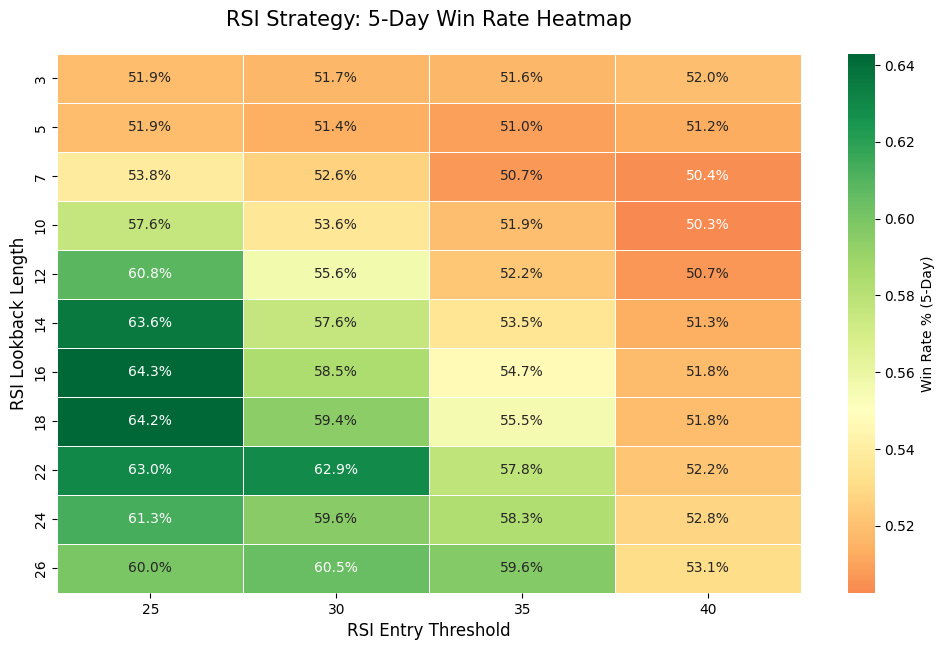

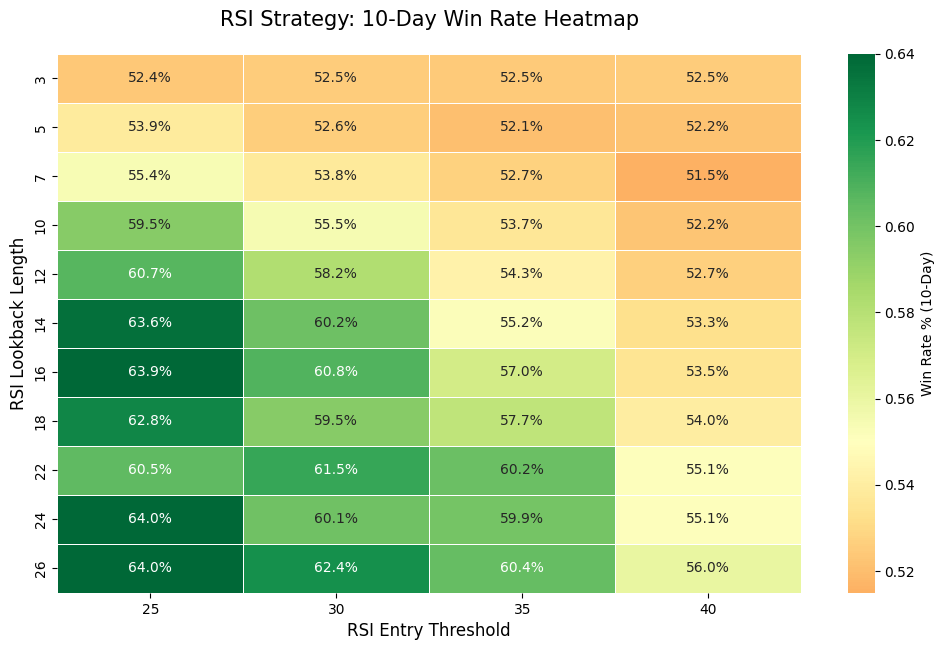

In [4]:
# Win Rate Heat Maps

# 1. Pivot the data for 5-Day Win Rate
heatmap_data_5d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_5D")

# 2. Set up the figure for 5-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 5-Day Win Rate
sns.heatmap(
    heatmap_data_5d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_5D"].min(),
    vmax=summary_df["Win_Rate_5D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (5-Day)'}
)

# 4. Labels for 5-Day Win Rate Heatmap
plt.title("RSI Strategy: 5-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for 10-Day Win Rate Heatmap ---

# 1. Pivot the data for 10-Day Win Rate
heatmap_data_10d = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Win_Rate_10D")

# 2. Set up the figure for 10-Day Win Rate Heatmap
plt.figure(figsize=(12, 7))

# 3. Create the heatmap for 10-Day Win Rate
sns.heatmap(
    heatmap_data_10d,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    vmin=summary_df["Win_Rate_10D"].min(),
    vmax=summary_df["Win_Rate_10D"].max(),
    center=0.55,
    linewidths=.5,
    cbar_kws={'label': 'Win Rate % (10-Day)'}
)

# 4. Labels for 10-Day Win Rate Heatmap
plt.title("RSI Strategy: 10-Day Win Rate Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

## Average Return Heatmaps

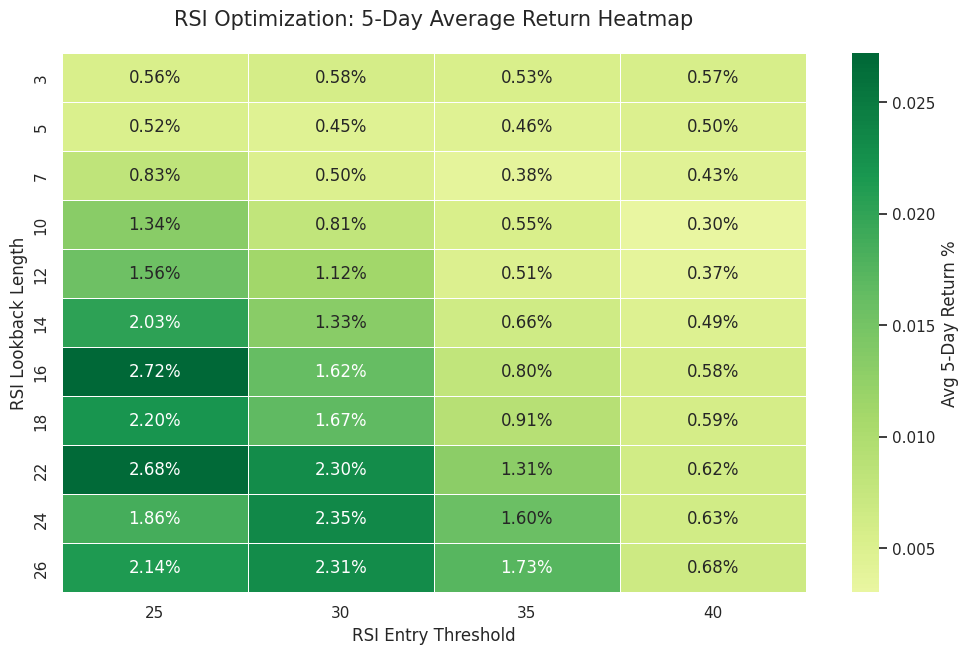

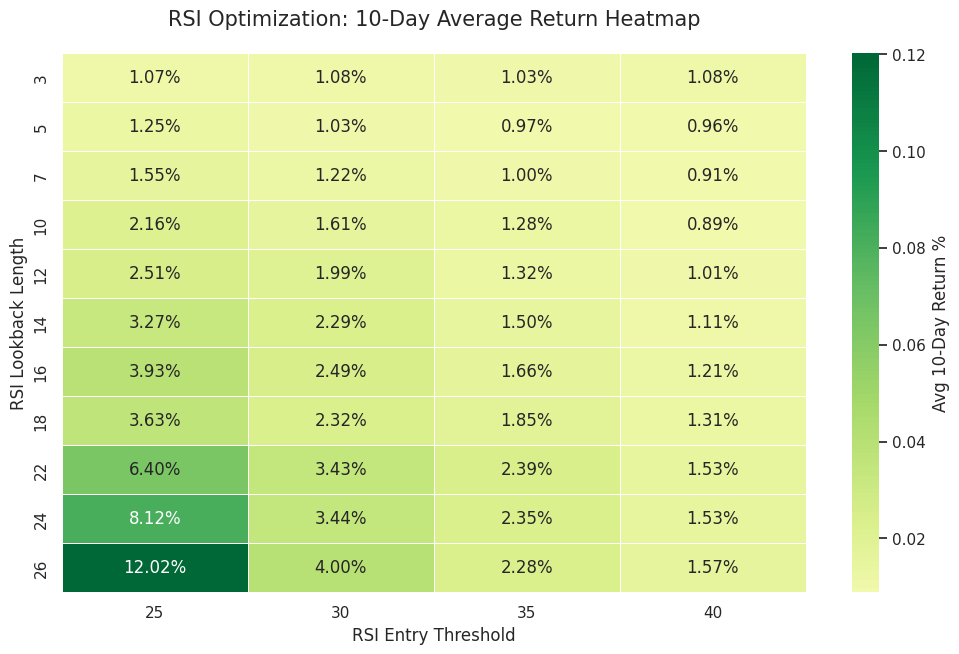

In [5]:
# Average Return Heatmaps

# 1. Pivot the data for Average 5-Day Return
heatmap_data_5d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_5D")

# 2. Set up the figure for Average 5-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
# vmin/vmax: Stretches the color range to your specific best and worst performers
# center=0: Ensures the color transition happens exactly at the break-even point
sns.heatmap(
    heatmap_data_5d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_5D"].min(),
    vmax=summary_df["Avg_5D"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 5-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 5-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

# --- Separator for Average 10-Day Return Heatmap ---

# 1. Pivot the data for Average 10-Day Return
heatmap_data_10d_avg = summary_df.pivot(index="RSI_Len", columns="RSI_Thresh", values="Avg_10D")

# 2. Set up the figure for Average 10-Day Return Heatmap
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")

# 3. Create the heatmap with optimized gradient parameters
sns.heatmap(
    heatmap_data_10d_avg,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    vmin=summary_df["Avg_10D"].min(),
    vmax=summary_df["Avg_10D"].max(),
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Avg 10-Day Return %'}
)

# 4. Labels and Title
plt.title("RSI Optimization: 10-Day Average Return Heatmap", fontsize=15, pad=20)
plt.xlabel("RSI Entry Threshold", fontsize=12)
plt.ylabel("RSI Lookback Length", fontsize=12)

plt.show()

### Monthly Performance Analysis for Specific RSI Parameters

Analyze the monthly performance (win rate and average return) for a chosen RSI Length and Threshold. This helps to see the consistency of the strategy over time.

In [6]:
# Monthly Performance Analysis for Specific RSI Parameters

target_rsi_len = 14  # @param {type: "raw"}
target_rsi_thresh = 25 # @param {type: "raw"}
trade_size_dollars = 1000 # @param {type: "raw"} Default trade size in dollars

# Filter the all_combined_trades_df for the selected RSI_Len and RSI_Thresh
monthly_trades = all_combined_trades_df[
    (all_combined_trades_df['RSI_Len'] == target_rsi_len) &
    (all_combined_trades_df['RSI_Thresh'] == target_rsi_thresh)
].copy()

if not monthly_trades.empty:
    # Ensure 'Date' is datetime and set as index if not already
    monthly_trades.index = pd.to_datetime(monthly_trades.index)

    # Extract Year and Month
    monthly_trades['Year'] = monthly_trades.index.year
    monthly_trades['Month'] = monthly_trades.index.month

    # Group by Year and Month and calculate performance metrics for 3D, 5D, and 10D
    monthly_performance = monthly_trades.groupby(['Year', 'Month']).agg(
        Trade_Count=('Ret_5D', 'count'), # Assuming trade count is consistent across Ret_nD
        Avg_3D_Ret=('Ret_3D', 'mean'),
        Win_Rate_3D=('Ret_3D', lambda x: (x > 0).mean()),
        Avg_5D_Ret=('Ret_5D', 'mean'),
        Win_Rate_5D=('Ret_5D', lambda x: (x > 0).mean()),
        Avg_10D_Ret=('Ret_10D', 'mean'),
        Win_Rate_10D=('Ret_10D', lambda x: (x > 0).mean())
    ).reset_index()

    # Calculate Monthly Dollar Return for 3D, 5D, and 10D, and Cumulative Monthly Dollar Value (based on 5D)
    monthly_performance['Monthly_Return_3D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_3D_Ret'] * trade_size_dollars
    monthly_performance['Monthly_Return_5D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_5D_Ret'] * trade_size_dollars
    monthly_performance['Monthly_Return_10D'] = monthly_performance['Trade_Count'] * monthly_performance['Avg_10D_Ret'] * trade_size_dollars
    monthly_performance['Cumulative_Monthly_Dollar_Value'] = monthly_performance['Monthly_Return_5D'].cumsum()

    print(f"\n--- Monthly Performance for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} (Trade Size: ${trade_size_dollars}) ---")
    # Display the monthly performance, focusing on all relevant monthly metrics
    display(monthly_performance[[
        'Year', 'Month', 'Trade_Count',
        'Avg_3D_Ret', 'Win_Rate_3D', 'Monthly_Return_3D',
        'Avg_5D_Ret', 'Win_Rate_5D', 'Monthly_Return_5D',
        'Avg_10D_Ret', 'Win_Rate_10D', 'Monthly_Return_10D'
    ]])
else:
    print(f"No trades found for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} in the collected trades.")


--- Monthly Performance for RSI_Len=14, RSI_Thresh=25 (Trade Size: $1000) ---


,Year,Month,Trade_Count,Avg_3D_Ret,Win_Rate_3D,Monthly_Return_3D,Avg_5D_Ret,Win_Rate_5D,Monthly_Return_5D,Avg_10D_Ret,Win_Rate_10D,Monthly_Return_10D
0,2021,8,34,0.004914,0.500000,167.082242,1.678797e-02,0.735294,570.791110,0.031011,0.705882,1054.384008
1,2021,9,16,0.000829,0.437500,13.270433,5.489877e-04,0.500000,8.783804,0.010068,0.625000,161.089256
2,2021,10,13,0.010832,0.769231,140.816226,1.314230e-02,0.846154,170.849891,0.025147,0.846154,326.914972
3,2021,11,16,-0.022927,0.375000,-366.832388,-1.239604e-02,0.312500,-198.336568,-0.025845,0.500000,-413.513203
4,2021,12,16,0.045072,0.812500,721.154998,6.132361e-02,0.750000,981.177738,0.019534,0.625000,312.538066
5,2022,1,60,0.017352,0.516667,1041.096960,1.484421e-02,0.583333,890.652501,0.041263,0.733333,2475.766858
6,2022,2,13,-0.011926,0.384615,-155.031687,6.842507e-04,0.538462,8.895259,-0.039887,0.384615,-518.536166
7,2022,3,21,0.092385,0.857143,1940.085412,8.200989e-02,0.809524,1722.207596,0.173222,1.000000,3637.665138
8,2022,4,8,0.024306,0.750000,194.445439,-1.653270e-02,0.625000,-132.261640,-0.090769,0.125000,-726.155938
9,2022,5,51,0.016748,0.588235,854.173393,2.217177e-02,0.607843,1130.760256,0.047073,0.627451,2400.714049


### Yearly Performance Analysis

In [7]:
# Yearly Performance Analysis

if not monthly_performance.empty:
    yearly_performance = monthly_performance.groupby('Year').agg(
        Yearly_Return_3D=('Monthly_Return_3D', 'sum'),
        Yearly_Return_5D=('Monthly_Return_5D', 'sum'),
        Yearly_Return_10D=('Monthly_Return_10D', 'sum')
    ).reset_index()

    print(f"\n--- Yearly Performance for RSI_Len={target_rsi_len}, RSI_Thresh={target_rsi_thresh} (Trade Size: ${trade_size_dollars}) ---")
    display(yearly_performance)
else:
    print("No monthly performance data to aggregate for yearly analysis.")


--- Yearly Performance for RSI_Len=14, RSI_Thresh=25 (Trade Size: $1000) ---


,Year,Yearly_Return_3D,Yearly_Return_5D,Yearly_Return_10D
0,2021,675.491511,1533.265973,1441.413099
1,2022,5429.564430,5418.641209,9996.921163
2,2023,1809.856291,2859.399409,7409.559942
3,2024,1171.386544,2103.268103,3646.360762
4,2025,5074.914440,5040.070661,6215.589189
5,2026,739.651285,1585.319033,1170.124407


## 2022 Back test

In [8]:
# 2022 Back test

# --- 1. Configuration & Symbol Loading ---
RSI_LEVELS = [25, 30, 35, 40]
RSI_LENGTHS = [7, 10, 12, 14, 16, 18, 20, 22, 24, 26]

# Data window to capture all of 2022 with buffers for indicators and returns
START_DATE = "2021-11-01"
END_DATE = "2023-01-20"

try:
    df_csv = pd.read_csv(OptionVolume200)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume200")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT", "AMD", "META"]

# --- 2. Yahoo-Style RSI Function ---
def calculate_rsi_yahoo(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    # Wilder's Smoothing logic
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# --- 3. Data Fetching & Vectorized Math ---
print(f"Fetching data from {START_DATE} to {END_DATE}...")
data_cache = {}
for s in SYMBOLS:
    try:
        df = yf.download(s, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)
        if df.empty: continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Vectorized Future Returns (Shifted backwards)
        df['Ret_3D'] = df['Close'].pct_change(3).shift(-3)
        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)
        df['Ret_10D'] = df['Close'].pct_change(10).shift(-10)

        data_cache[s] = df
    except:
        continue

# --- 4. Parameter Sweep for 2022 ---
all_results = []

print("Running 2022 Analysis...")
for rsi_len in RSI_LENGTHS:
    for rsi_thresh in RSI_LEVELS:
        param_trades = []

        for symbol, df_orig in data_cache.items():
            df = df_orig.copy()
            df['RSI'] = calculate_rsi_yahoo(df['Close'], period=rsi_len)

            # --- CRITICAL FILTER: Only include signals that triggered in 2022 ---
            mask_2022 = (df.index >= "2022-01-01") & (df.index <= "2022-12-31")
            trades = df[mask_2022 & (df['RSI'] < rsi_thresh)].dropna(subset=['RSI', 'Ret_10D']).copy()

            if not trades.empty:
                trades['RSI_Len'] = rsi_len
                trades['RSI_Thresh'] = rsi_thresh
                trades['Symbol'] = symbol
                param_trades.append(trades)

        if param_trades:
            combined = pd.concat(param_trades)
            all_results.append({
                "RSI_Len": rsi_len,
                "RSI_Thresh": rsi_thresh,
                "Avg_3D": combined['Ret_3D'].mean(),
                "Avg_5D": combined['Ret_5D'].mean(),
                "Avg_10D": combined['Ret_10D'].mean(),
                "Win_Rate_3D": (combined['Ret_3D'] > 0).mean(),
                "Win_Rate_5D": (combined['Ret_5D'] > 0).mean(),
                "Win_Rate_10D": (combined['Ret_10D'] > 0).mean(),
                "Trade_Count": len(combined)
            })

# --- 5. Summary Table ---
if all_results:
    summary_df_2022 = pd.DataFrame(all_results)
    summary_df_2022 = summary_df_2022.sort_values(by="Avg_5D", ascending=False)

    print("\n--- 2022 RSI BACKTEST SUMMARY ---")
    display(summary_df_2022)
    summary_df_2022.to_csv("rsi_results_2022.csv", index=False)
else:
    print("No trades triggered in 2022 with current parameters.")

Loaded 200 symbols from OptionVolume200
Fetching data from 2021-11-01 to 2023-01-20...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IBIT']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CRWV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NBIS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-11-01 -> 2023-01-20) (Yahoo error = "Data doesn\'t exist for startDate = 1635739200, endDate = 1674190800")')
ERROR:yfinance:
1 Failed download:
E

Running 2022 Analysis...

--- 2022 RSI BACKTEST SUMMARY ---


,RSI_Len,RSI_Thresh,Avg_3D,Avg_5D,Avg_10D,Win_Rate_3D,Win_Rate_5D,Win_Rate_10D,Trade_Count
24,20,25,0.036127,0.038895,0.055785,0.601399,0.622378,0.664336,143
36,26,25,0.044011,0.033842,0.062479,0.644444,0.666667,0.666667,45
20,18,25,0.026891,0.031440,0.043069,0.542017,0.592437,0.626050,238
32,24,25,0.036761,0.030958,0.050312,0.631579,0.666667,0.649123,57
16,16,25,0.023815,0.027543,0.039366,0.555256,0.590296,0.609164,371
28,22,25,0.028562,0.027387,0.040839,0.578947,0.610526,0.652632,95
12,14,25,0.024983,0.026113,0.039325,0.589085,0.616372,0.622793,623
25,20,30,0.023371,0.023707,0.030494,0.572368,0.584430,0.584430,912
8,12,25,0.022342,0.021478,0.030236,0.579926,0.598513,0.597584,1076
21,18,30,0.021060,0.021061,0.027599,0.570724,0.589638,0.586349,1216


## SMA Analysis



This code performs a comprehensive backtest of an RSI trading strategy, analyzing how 5-day forward win rates change when trades are initiated above versus below various Simple Moving Averages (SMAs). It systematically sweeps through different RSI lengths and thresholds, then categorizes and reports the performance of each parameter set based on its trend relative to 50, 100, 150, and 200-day SMAs.

In [9]:
# SMA Analysis

# --- 1. Configuration ---
RSI_LEVELS = [25, 30]
RSI_LENGTHS = [10, 12, 14, 16, 18, 20, 22, 24, 26]
SMA_PERIODS = [50, 100, 150, 200]

try:
    df_csv = pd.read_csv(OptionVolume200)
    symbol_col = [c for c in df_csv.columns if 'symbol' in c.lower()][0]
    SYMBOLS = df_csv[symbol_col].str.strip().unique().tolist()
    print(f"Loaded {len(SYMBOLS)} symbols from OptionVolume200")
except Exception as e:
    print(f"Could not load CSV: {e}. Falling back to default list.")
    SYMBOLS = ["TSLA", "SPY", "QQQ", "NVDA", "AAPL", "MSFT", "AMD", "META"]

# --- 2. Precision RSI (Wilder's Smoothing) ---
def calculate_rsi_yahoo(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

# --- 3. Data Fetching & Vectorized Calculation ---
print("Fetching 7 years of data (providing 2-year warm-up for SMAs)...")
data_cache = {}
study_start_date = datetime.now() - timedelta(days=5*365)

for s in SYMBOLS:
    try:
        df = yf.download(s, period="7y", interval="1d", progress=False, auto_adjust=True)
        if df.empty or len(df) < 250: continue

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df['Ret_5D'] = df['Close'].pct_change(5).shift(-5)

        for sma in SMA_PERIODS:
            df[f'SMA_{sma}'] = df['Close'].rolling(window=sma).mean()
            df[f'Above_SMA_{sma}'] = df['Close'] > df[f'SMA_{sma}']

        df = df.loc[df.index >= study_start_date].copy()
        data_cache[s] = df
    except:
        continue

# --- 4. Backtest Sweep ---
all_results = []

for rsi_len in RSI_LENGTHS:
    for rsi_thresh in RSI_LEVELS:
        param_trades = []

        for symbol, df_orig in data_cache.items():
            df = df_orig.copy()
            df['RSI'] = calculate_rsi_yahoo(df['Close'], period=rsi_len)

            trades = df[df['RSI'] < rsi_thresh].dropna(subset=['RSI', 'Ret_5D']).copy()
            if not trades.empty:
                trades['RSI_Len'] = rsi_len
                trades['RSI_Thresh'] = rsi_thresh
                param_trades.append(trades)

        if param_trades:
            combined = pd.concat(param_trades)

            res = {
                "RSI_Len": rsi_len,
                "RSI_Thresh": rsi_thresh,
                "Trades": len(combined),
                "WR_All": (combined['Ret_5D'] > 0).mean()
            }

            for sma in SMA_PERIODS:
                above_df = combined[combined[f'Above_SMA_{sma}'] == True]
                below_df = combined[combined[f'Above_SMA_{sma}'] == False]

                # Above Stats
                res[f'WR_Above_{sma}'] = (above_df['Ret_5D'] > 0).mean() if len(above_df) > 0 else np.nan
                res[f'Cnt_Above_{sma}'] = len(above_df)

                # Below Stats
                res[f'WR_Below_{sma}'] = (below_df['Ret_5D'] > 0).mean() if len(below_df) > 0 else np.nan
                res[f'Cnt_Below_{sma}'] = len(below_df)

            all_results.append(res)

# --- 5. Summary Display ---
if all_results:
    summary_df = pd.DataFrame(all_results)
    summary_df = summary_df.sort_values(by="WR_All", ascending=False)

    # Building the display list dynamically
    display_cols = ["RSI_Len", "RSI_Thresh", "Trades", "WR_All"]
    for sma in SMA_PERIODS:
        display_cols.extend([f"WR_Above_{sma}", f"Cnt_Above_{sma}", f"WR_Below_{sma}", f"Cnt_Below_{sma}"])

    print("\n" + "="*200)
    print("WIN RATE & COUNT COMPARISON: ABOVE VS BELOW SMA TRENDLINES (5-Day Forward Return)")
    print("="*200)

    # Optimized print for wide tables
    print(summary_df[display_cols].to_string(
        index=False,
        float_format=lambda x: f"{x:.1%}" if isinstance(x, (float, np.float64)) and 0 <= x <= 1 else f"{int(x)}" if isinstance(x, (float, np.float64)) and x > 1 else str(x),
        na_rep="N/A"
    ))
    print("="*200)

    summary_df.to_csv("rsi_complete_trend_results_with_counts.csv", index=False)
else:
    print("No trades found.")

Loaded 200 symbols from OptionVolume200
Fetching 7 years of data (providing 2-year warm-up for SMAs)...

WIN RATE & COUNT COMPARISON: ABOVE VS BELOW SMA TRENDLINES (5-Day Forward Return)
 RSI_Len  RSI_Thresh  Trades  WR_All  WR_Above_50  Cnt_Above_50  WR_Below_50  Cnt_Below_50  WR_Above_100  Cnt_Above_100  WR_Below_100  Cnt_Below_100  WR_Above_150  Cnt_Above_150  WR_Below_150  Cnt_Below_150  WR_Above_200  Cnt_Above_200  WR_Below_200  Cnt_Below_200
      14          25    2398   63.1%          N/A             0        63.1%          2398         75.0%              4         63.1%           2394         73.7%             38         62.9%           2360         74.7%             91         62.6%           2307
      20          25     511   63.0%          N/A             0        63.0%           511           N/A              0         63.0%            511           N/A              0         63.0%            511           N/A              0         63.0%            511
      18          